
🌌 Live Aurora Forecast (NOAA data)
Kp index: 3.67
Solar wind speed: 463 km/s
IMF Bz: 14.4 nT

🌠 Forecast
----------------------------------
Aurora probability: 13%
Southern visibility boundary: ~55.5° latitude
Status: Quiet


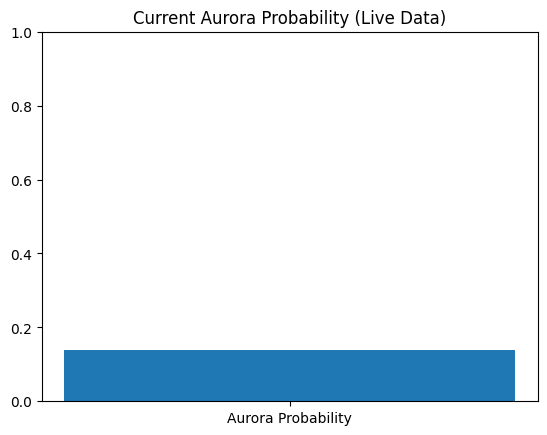

In [ ]:
import requests
import numpy as np
import matplotlib.pyplot as plt

# API ENDPOINTS (NOAA SWPC)

KP_API = "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json"
SOLAR_WIND_API = "https://services.swpc.noaa.gov/products/solar-wind/plasma-1-day.json"
IMF_API = "https://services.swpc.noaa.gov/products/solar-wind/mag-1-day.json"

# ======================================================
# BASE AURORA MODEL
# ======================================================

def aurora_probability(kp):
    if kp < 2:
        return 0.05
    elif kp < 4:
        return 0.20
    elif kp < 5:
        return 0.40
    elif kp < 6:
        return 0.60
    elif kp < 7:
        return 0.80
    else:
        return 0.95


def aurora_latitude_boundary(kp):
    return 66.5 - (kp * 3)


def solar_wind_boost(speed, bz):
    speed_factor = 0.9 if speed < 400 else 1.0 if speed < 600 else 1.2
    bz_factor = 0.7 if bz > 0 else 1.0 if bz > -5 else 1.4
    return speed_factor * bz_factor


# ======================================================
# API FETCH FUNCTIONS
# ======================================================

def fetch_latest_kp():
    data = requests.get(KP_API).json()
    latest = data[-1]
    return float(latest[1])


def fetch_latest_solar_wind():
    data = requests.get(SOLAR_WIND_API).json()
    latest = data[-1]
    speed = float(latest[2])
    return speed


def fetch_latest_bz():
    data = requests.get(IMF_API).json()
    latest = data[-1]
    bz = float(latest[6])
    return bz


# ======================================================
# MAIN
# ======================================================

print("\n🌌 Live Aurora Forecast (NOAA data)")
print("==================================")

try:
    kp = fetch_latest_kp()
    solar_wind_speed = fetch_latest_solar_wind()
    imf_bz = fetch_latest_bz()
except Exception as e:
    print("❌ Failed to fetch live data:", e)
    exit()

print(f"Kp index: {kp}")
print(f"Solar wind speed: {solar_wind_speed:.0f} km/s")
print(f"IMF Bz: {imf_bz:.1f} nT")

boost = solar_wind_boost(solar_wind_speed, imf_bz)
prob = min(aurora_probability(kp) * boost, 1.0)
boundary = aurora_latitude_boundary(kp)

print("\n🌠 Forecast")
print("----------------------------------")
print(f"Aurora probability: {int(prob * 100)}%")
print(f"Southern visibility boundary: ~{boundary:.1f}° latitude")

if prob < 0.3:
    print("Status: Quiet")
elif prob < 0.6:
    print("Status: Moderate aurora possible")
else:
    print("Status: Strong aurora likely")

# ======================================================
# SIMPLE VISUALIZATION
# ======================================================

plt.figure()
plt.bar(["Aurora Probability"], [prob])
plt.ylim(0, 1)
plt.title("Current Aurora Probability (Live Data)")
plt.show()



🌌 Live Space Weather
--------------------
Kp index: 3.67
Solar wind speed: 450 km/s
IMF Bz: 13.9 nT
Aurora probability: 13%


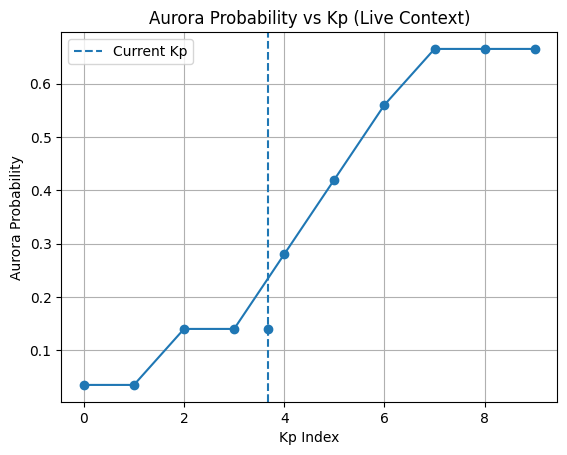

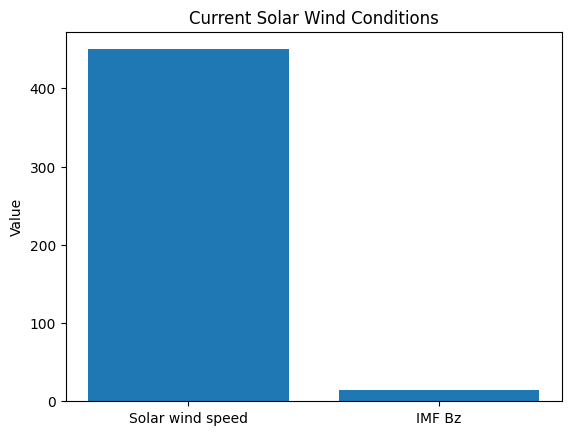

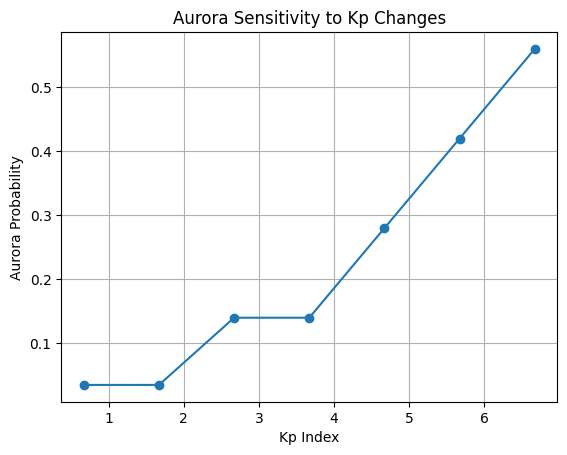

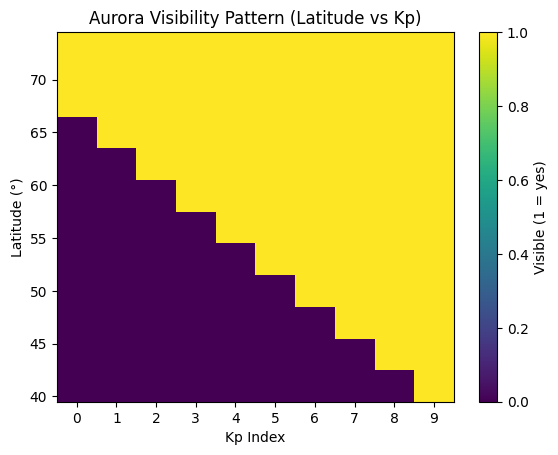

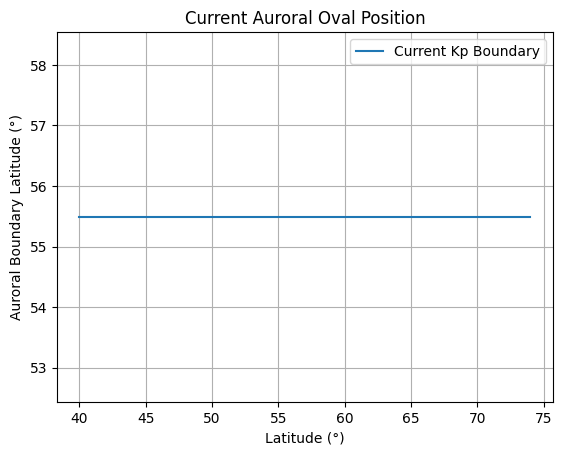

In [ ]:
import requests
import numpy as np
import matplotlib.pyplot as plt

KP_API = "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json"
SOLAR_WIND_API = "https://services.swpc.noaa.gov/products/solar-wind/plasma-1-day.json"
IMF_API = "https://services.swpc.noaa.gov/products/solar-wind/mag-1-day.json"

def aurora_probability(kp):
    if kp < 2:
        return 0.05
    elif kp < 4:
        return 0.20
    elif kp < 5:
        return 0.40
    elif kp < 6:
        return 0.60
    elif kp < 7:
        return 0.80
    else:
        return 0.95


def aurora_latitude_boundary(kp):
    return 66.5 - (kp * 3)


def solar_wind_boost(speed, bz):
    speed_factor = 0.9 if speed < 400 else 1.0 if speed < 600 else 1.2
    bz_factor = 0.7 if bz > 0 else 1.0 if bz > -5 else 1.4
    return speed_factor * bz_factor


# API FETCHING
def fetch_latest_kp():
    data = requests.get(KP_API).json()
    return float(data[-1][1])


def fetch_latest_speed():
    data = requests.get(SOLAR_WIND_API).json()
    return float(data[-1][2])


def fetch_latest_bz():
    data = requests.get(IMF_API).json()
    return float(data[-1][6])

# FETCH LIVE DATA


kp = fetch_latest_kp()
speed = fetch_latest_speed()
bz = fetch_latest_bz()

boost = solar_wind_boost(speed, bz)
current_prob = min(aurora_probability(kp) * boost, 1.0)

print("\n🌌 Live Space Weather")
print("--------------------")
print(f"Kp index: {kp}")
print(f"Solar wind speed: {speed:.0f} km/s")
print(f"IMF Bz: {bz:.1f} nT")
print(f"Aurora probability: {int(current_prob*100)}%")


# GRAPH 1: Probability vs Kp 

kp_range = np.arange(0, 10)
prob_curve = [aurora_probability(k) * boost for k in kp_range]

plt.figure()
plt.plot(kp_range, prob_curve, marker='o')
plt.axvline(kp, linestyle='--', label="Current Kp")
plt.scatter([kp], [current_prob])
plt.xlabel("Kp Index")
plt.ylabel("Aurora Probability")
plt.title("Aurora Probability vs Kp (Live Context)")
plt.legend()
plt.grid(True)
plt.show()

# GRAPH 2: Solar wind contribution

plt.figure()
plt.bar(["Solar wind speed", "IMF Bz"], [speed, bz])
plt.title("Current Solar Wind Conditions")
plt.ylabel("Value")
plt.show()

# GRAPH 3: Sensitivity to Kp changes

kp_sensitivity = np.arange(max(0, kp - 3), min(9, kp + 4))
sensitivity_probs = [
    min(aurora_probability(k) * boost, 1.0) for k in kp_sensitivity
]

plt.figure()
plt.plot(kp_sensitivity, sensitivity_probs, marker='o')
plt.xlabel("Kp Index")
plt.ylabel("Aurora Probability")
plt.title("Aurora Sensitivity to Kp Changes")
plt.grid(True)
plt.show()


# GRAPH 4: Latitude vs Kp visibility map

latitudes = np.arange(40, 75)
visibility = np.zeros((len(latitudes), len(kp_range)))

for i, lat in enumerate(latitudes):
    for j, k in enumerate(kp_range):
        visibility[i, j] = 1 if lat >= aurora_latitude_boundary(k) else 0

plt.figure()
plt.imshow(visibility, aspect="auto", origin="lower")
plt.colorbar(label="Visible (1 = yes)")
plt.xticks(range(len(kp_range)), kp_range)
plt.yticks(range(0, len(latitudes), 5), latitudes[::5])
plt.xlabel("Kp Index")
plt.ylabel("Latitude (°)")
plt.title("Aurora Visibility Pattern (Latitude vs Kp)")
plt.show()


# GRAPH 5: Where we are on the oval

plt.figure()
plt.plot(latitudes,
         [aurora_latitude_boundary(kp)] * len(latitudes),
         label="Current Kp Boundary")
plt.xlabel("Latitude (°)")
plt.ylabel("Auroral Boundary Latitude (°)")
plt.title("Current Auroral Oval Position")
plt.legend()
plt.grid(True)
plt.show()
